# Financial Stress Cascade: From Income Pressure to Harmful Coping Behaviors

This notebook analyzes how financial stress creates cascading constraints that drive households toward behaviors harmful to both their financial stability and physical well-being, using the 2024 Federal Reserve Survey of Household Economics and Decisionmaking (SHED).

**Data Source**: Board of Governors of the Federal Reserve System Survey of Household Economics and Decisionmaking [dataset] (Washington: Board of Governors, 2025), https://doi.org/10.17016/datasets.002

**Sample**: 7,858 non-retired working-age respondents from the 2024 SHED

**Analysis Focus**:
1. **Household Spending Distribution** - Baseline prevalence of financial stress
2. **Intergenerational Financial Patterns** - How vulnerability persists across generations
3. **Inflation Response Escalation** - Active coping mechanisms and escalation patterns
4. **Financial Stress and Harmful Behaviours** - Consequences: healthcare delays + predatory finance

**Narrative Arc**: This analysis follows a logical progression from establishing the baseline (who's struggling), to understanding root causes (why vulnerability persists), to examining responses (how households cope), and finally revealing consequences (the harm that results from inadequate support systems).

## Setup and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib_venn import venn3
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Color palettes
AGE_COLORS = {
    '18-29': '#E63946',  # Red
    '30-44': '#F77F00',  # Orange
    '45+': '#06AED5'     # Blue
}

# Financial stress color gradient  
STRESS_COLORS = {
    'Less than your income': '#2E7D32',       # Green - stable
    'The same as your income': '#FFA726',     # Orange - getting by
    'More than your income': '#E63946'        # Red - stressed
}

# Figure settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

## Data Loading and Preparation

In [2]:
# Load data (non-retired working-age adults)
df = pd.read_csv('data_optimized.csv', low_memory=False)

print(f"Total sample size: {len(df):,}")
print(f"\nColumns: {len(df.columns)}")

Total sample size: 7,858

Columns: 385


In [3]:
# Create short I20 labels (primary financial stress indicator)
i20_short_labels = {
    'Less than your income': 'Less than income',
    'The same as your income': 'Same as income',
    'More than your income': 'More than income'
}
df['i20_label'] = df['I20'].map(i20_short_labels)

print("Financial stress distribution (I20 - Spending relative to income):")
print(df['i20_label'].value_counts())
print(f"\nPercentage spending more than income: {(df['I20']=='More than your income').sum() / len(df) * 100:.1f}%")

Financial stress distribution (I20 - Spending relative to income):
i20_label
Less than income    3888
Same as income      2391
More than income    1579
Name: count, dtype: int64

Percentage spending more than income: 20.1%


In [4]:
# Create income brackets from I40 (15 categories → 4 brackets)
income_bracket_mapping = {
    'Less than $5,000': '<$40k',
    '$5,000 to $9,999': '<$40k',
    '$10,000 to $14,999': '<$40k',
    '$15,000 to $19,999': '<$40k',
    '$20,000 to $24,999': '<$40k',
    '$25,000 to $29,999': '<$40k',
    '$30,000 to $34,999': '<$40k',
    '$35,000 to $39,999': '<$40k',
    '$40,000 to $49,999': '$40k-$99k',
    '$50,000 to $59,999': '$40k-$99k',
    '$60,000 to $74,999': '$40k-$99k',
    '$75,000 to $99,999': '$40k-$99k',
    '$100,000 to $149,999': '$100k-$199k',
    '$150,000 to $199,999': '$100k-$199k',
    '$200,000 or more': '$200k+'
}

df['income_bracket'] = df['I40'].map(income_bracket_mapping)

print("Income bracket distribution:")
print(df['income_bracket'].value_counts())

Income bracket distribution:
income_bracket
$40k-$99k      2368
$100k-$199k    2299
<$40k          2150
$200k+         1041
Name: count, dtype: int64


In [5]:
# Create clean industry labels (top industries + "Other")
# Get top 10 industries by count
top_industries = df[df['ind1'] != -2]['ind1'].value_counts().head(10).index.tolist()

def clean_industry_name(ind):
    if ind == -2 or pd.isna(ind):
        return 'Not employed/NA'
    elif ind not in top_industries:
        return 'Other'
    else:
        return ind

df['industry_clean'] = df['ind1'].apply(clean_industry_name)

print("\nTop industries + Other:")
print(df['industry_clean'].value_counts().head(12))


Top industries + Other:
industry_clean
Other                                                                                                    1970
-2                                                                                                       1354
Professional, Scientific, Technical, and Business Services                                                816
Health Care (including Elder Care, Home Health Care)                                                      786
Education and Tutoring                                                                                    653
Retail/Stores/Shopping (including Online Retail)                                                          529
Factory, Manufacturing, and Woodworking                                                                   465
Finance, Banking, and Insurance                                                                           424
Delivery Services, Warehousing, and Transportation (including Air, Rail, Water, 

In [6]:
# Create short I9 labels (income volatility)
i9_short_labels = {
    'Roughly the same amount each month': 'Roughly same',
    'Occasionally varies from month to month': 'Occasionally varies',
    'Varies quite often from month to month': 'Varies quite often'
}
df['i9_label'] = df['I9'].map(i9_short_labels)

print("Income volatility distribution:")
print(df['i9_label'].value_counts())

Income volatility distribution:
i9_label
Roughly same           5330
Occasionally varies    1796
Varies quite often      732
Name: count, dtype: int64


## Helper Functions

In [7]:
def weighted_pct(df_subset, condition_col, condition_val='Yes', weight_col='weight_pop'):
    """
    Calculate weighted percentage where condition is met
    """
    total_weight = df_subset[weight_col].sum()
    if total_weight == 0:
        return 0
    
    condition_weight = df_subset[df_subset[condition_col] == condition_val][weight_col].sum()
    return (condition_weight / total_weight) * 100

def weighted_pct_by_group(df, condition_col, group_col='I20', condition_val='Yes', weight_col='weight_pop'):
    """
    Calculate weighted percentage by group where condition is met
    """
    results = {}
    for group in sorted(df[group_col].dropna().unique()):
        group_df = df[df[group_col] == group]
        results[group] = weighted_pct(group_df, condition_col, condition_val, weight_col)
    return results

---
# Chart 1: Household Spending Distribution
## Waterfall Chart

**Research Question**: What is the baseline distribution of working-age households across spending patterns?

**Variable**: I20 - Spending relative to income

**Methodology**: Calculate weighted percentage distribution (using `weight_pop`) across three categories:
1. Spending < Income (financially stable)
2. Spending = Income (balanced budget)
3. Spending > Income (overspending/financially stressed)

**Sample**: N=7,858 non-retired working-age respondents

**Purpose**: Establishes the foundation for all subsequent analyses by showing how many households are in each financial health category.

In [8]:
# Calculate weighted percentage distribution and US household counts

# US household total from FRED (https://fred.stlouisfed.org/series/TTLHH)
US_HOUSEHOLDS = 132_216_000

# Define spending categories
spending_categories = [
    ('Less than your income', 'Spending < Income', '#81C784'),  # Green
    ('The same as your income', 'Spending = Income', '#FFA726'),  # Orange
    ('More than your income', 'Spending > Income', '#E63946')    # Red
]

# Calculate weighted percentages
total_weight = df['weight_pop'].sum()

waterfall_data = []
cumulative_pct = 0
cumulative_count = 0

print("Weighted distribution:")
print("=" * 70)

for i20_val, label, color in spending_categories:
    subset = df[df['I20'] == i20_val]
    category_weight = subset['weight_pop'].sum()
    pct = (category_weight / total_weight) * 100
    household_count = (pct / 100) * US_HOUSEHOLDS
    
    waterfall_data.append({
        'category': label,
        'percentage': pct,
        'household_count': household_count,
        'start_pct': cumulative_pct,
        'end_pct': cumulative_pct + pct,
        'start_count': cumulative_count,
        'end_count': cumulative_count + household_count,
        'color': color
    })
    
    cumulative_pct += pct
    cumulative_count += household_count
    
    print(f"{label:20s}: {pct:5.1f}% = {household_count/1_000_000:.1f}M households (n={len(subset):,})")

print("=" * 70)
print(f"Total: {cumulative_pct:.1f}% = {cumulative_count/1_000_000:.1f}M households")

waterfall_df = pd.DataFrame(waterfall_data)

Weighted distribution:
Spending < Income   :  48.7% = 64.4M households (n=3,888)
Spending = Income   :  30.9% = 40.8M households (n=2,391)
Spending > Income   :  20.5% = 27.0M households (n=1,579)
Total: 100.0% = 132.2M households


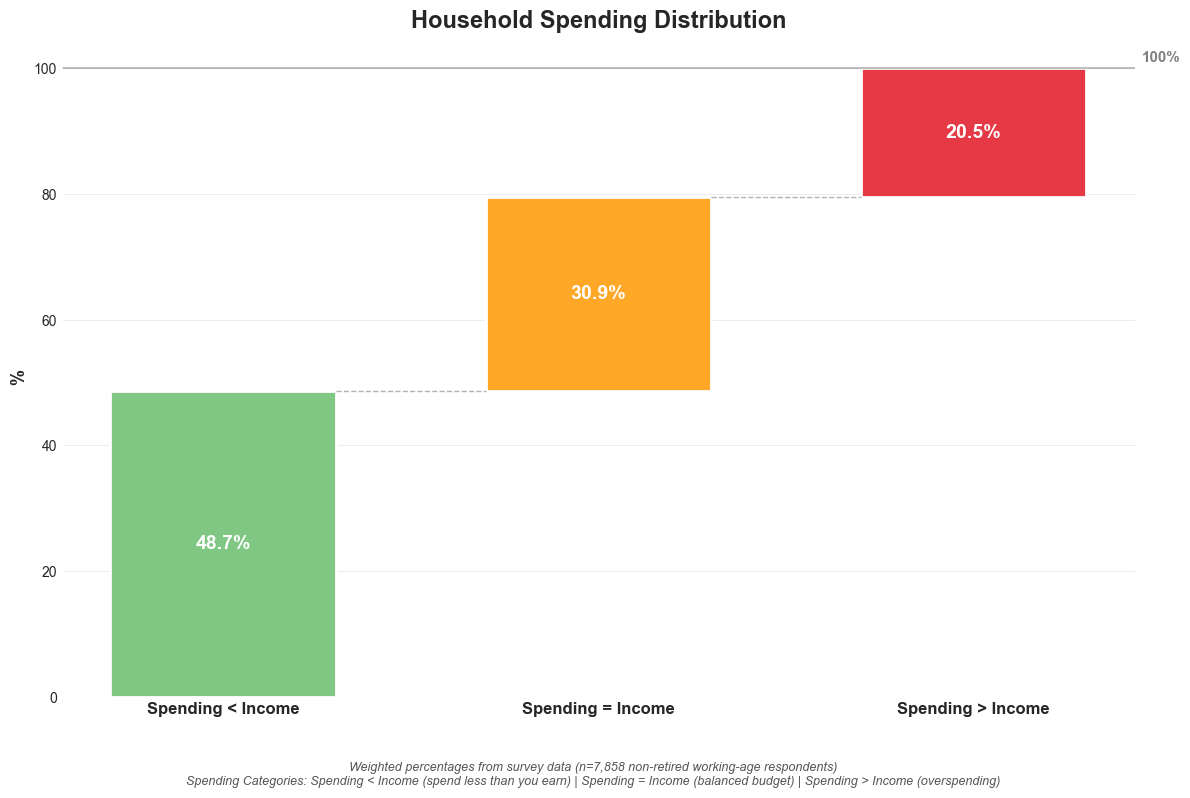


KEY INSIGHTS

Financially stable (spending < income): 48.7% = 64.4M households
Financially stressed (spending > income): 20.5% = 27.0M households

27.0 million working-age households are overspending,
creating vulnerability to financial shocks and harmful coping behaviors.


In [9]:
# Create waterfall chart with percentages
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')
ax.set_facecolor('white')

# Create waterfall bars
bar_width = 0.6
x_positions = np.arange(len(waterfall_df))

for idx, row in waterfall_df.iterrows():
    # Draw the bar from start to end (in percentages)
    height = row['percentage']
    bottom = row['start_pct']
    
    # Main bar
    bar = ax.bar(idx, height, bar_width, bottom=bottom,
                color=row['color'], edgecolor='white', linewidth=2)
    
    # Add percentage label in the center of the bar
    mid_y = bottom + height / 2
    ax.text(idx, mid_y, f"{height:.1f}%",
           ha='center', va='center', fontsize=14, fontweight='bold',
           color='white')
    
    # Add connector line to next bar (except for last bar)
    if idx < len(waterfall_df) - 1:
        ax.plot([idx + bar_width/2, idx + 1 - bar_width/2],
               [row['end_pct'], row['end_pct']],
               'k--', linewidth=1, alpha=0.3)

# Customize the plot
ax.set_xticks(x_positions)
ax.set_xticklabels(waterfall_df['category'], fontsize=12, fontweight='bold')
ax.set_ylabel('%', fontsize=13, fontweight='bold')
ax.set_title('Household Spending Distribution',
            fontsize=17, fontweight='bold', pad=20)

# Set y-axis to show 0-100%
ax.set_ylim(0, 102)
ax.set_yticks(np.arange(0, 101, 20))

# Add horizontal line at 100%
ax.axhline(y=100, color='gray', linestyle='-', linewidth=1.5, alpha=0.5)
ax.text(len(waterfall_df) - 0.5, 101, '100%',
       ha='center', fontsize=11, fontweight='bold', color='gray')

# Minimal styling
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Footnote
footnote_text = (
    "Weighted percentages from survey data (n=7,858 non-retired working-age respondents)\n"
    "Spending Categories: Spending < Income (spend less than you earn) | Spending = Income (balanced budget) | Spending > Income (overspending)"
)
fig.text(0.5, 0.01, footnote_text, ha='center', fontsize=9,
        color='#555', style='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

# Print key insights
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

overspending_pct = waterfall_df[waterfall_df['category'] == 'Spending > Income']['percentage'].values[0]
overspending_count = waterfall_df[waterfall_df['category'] == 'Spending > Income']['household_count'].values[0]
stable_pct = waterfall_df[waterfall_df['category'] == 'Spending < Income']['percentage'].values[0]
stable_count = waterfall_df[waterfall_df['category'] == 'Spending < Income']['household_count'].values[0]

print(f"\nFinancially stable (spending < income): {stable_pct:.1f}% = {stable_count/1_000_000:.1f}M households")
print(f"Financially stressed (spending > income): {overspending_pct:.1f}% = {overspending_count/1_000_000:.1f}M households")
print(f"\n{overspending_count/1_000_000:.1f} million working-age households are overspending,")
print("creating vulnerability to financial shocks and harmful coping behaviors.")

---
# Chart 2: Intergenerational Financial Patterns
## Sankey Diagram

**Research Question**: How does parental education predict current household financial outcomes?

**Variables**:
- **CH2A**: Parents' highest level of education
- **I20**: Current spending status (spending relative to income)

**Sample**: N=7,858

**Methodology**: Sankey flow diagram showing how parental education levels connect to current financial stress patterns.

**Purpose**: Demonstrates the root causes of financial vulnerability - how disadvantage persists across generations, creating structural barriers to financial stability.

In [10]:
# Filter to valid CH2A responses
intgen_df = df[~df['CH2A'].isin(["Don't know", 'Refused', np.nan])].copy()

print(f"Sample for intergenerational analysis: {len(intgen_df):,}")
print(f"\nParents' education distribution:")
print(intgen_df['CH2A'].value_counts())

Sample for intergenerational analysis: 7,832

Parents' education distribution:
CH2A
High school degree or GED          2223
Bachelor’s degree                  1582
Graduate degree                    1228
Some college but no degree          814
Less than high school degree        725
Associate degree                    518
Certificate or technical degree     444
Don’t know                          298
Name: count, dtype: int64


In [11]:
# Build Sankey: CH2A → I20
# Get actual education categories from the data (in desired order)
# Note: Data uses curly apostrophe in "Bachelor's degree", so we get values dynamically
available_edu = [e for e in intgen_df['CH2A'].unique() if pd.notna(e)]

# Define desired order (using keywords to match)
edu_order_keywords = [
    'Less than high school',
    'High school degree or GED',
    'Some college but no degree',
    'Certificate or technical degree',
    'Associate degree',
    'Bachelor',  # Keyword to find Bachelor's degree
    'Graduate degree'
]

# Match keywords to actual values from data
parent_edu_cats = []
for keyword in edu_order_keywords:
    if keyword == 'Bachelor':
        # Special handling for Bachelor's degree (has apostrophe)
        matches = [e for e in available_edu if 'bachelor' in str(e).lower()]
    else:
        matches = [e for e in available_edu if keyword.lower() in str(e).lower()]
    
    if matches:
        parent_edu_cats.append(matches[0])

i20_cats = ['Less than income', 'Same as income', 'More than income']

node_labels = parent_edu_cats + i20_cats

source = []
target = []
value = []
link_colors = []

for i, edu in enumerate(parent_edu_cats):
    for j, i20_label in enumerate(i20_cats):
        flow_count = len(intgen_df[(intgen_df['CH2A'] == edu) & 
                                   (intgen_df['i20_label'] == i20_label)])
        if flow_count > 0:
            source.append(i)
            target.append(len(parent_edu_cats) + j)
            value.append(flow_count)
            
            # Color by I20 outcome
            if j == 0:  # Less than income (good)
                link_colors.append('rgba(46, 125, 50, 0.4)')  # Green
            elif j == 1:  # Same as income
                link_colors.append('rgba(255, 167, 38, 0.4)')  # Orange
            else:  # More than income (stressed)
                link_colors.append('rgba(230, 57, 70, 0.4)')  # Red

print(f"\nTotal links: {len(source)}")
print(f"Total respondents in flows: {sum(value):,}")
print(f"\nEducation categories used (from data):")
for i, edu in enumerate(parent_edu_cats):
    count = (intgen_df['CH2A'] == edu).sum()
    print(f"  {i}: {edu} (n={count:,})")


Total links: 21
Total respondents in flows: 7,534

Education categories used (from data):
  0: Less than high school degree (n=725)
  1: High school degree or GED (n=2,223)
  2: Some college but no degree (n=814)
  3: Certificate or technical degree (n=444)
  4: Associate degree (n=518)
  5: Bachelor’s degree (n=1,582)
  6: Graduate degree (n=1,228)


In [12]:
# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=['#757575'] * len(parent_edu_cats) +  # Gray for parent edu
              ['#2E7D32', '#FFA726', '#E63946'],    # Green/Orange/Red for I20
        hovertemplate='%{label}<br>Count: %{value:,}<extra></extra>'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>Count: %{value:,}<extra></extra>'
    )
)])

fig.update_layout(
    title={
        'text': "Intergenerational Financial Patterns:<br>Parents' Education → Current Financial Outcomes",
        'font': {'size': 18, 'family': 'Arial, sans-serif'},
        'x': 0.5,
        'xanchor': 'center'
    },
    font=dict(size=11, family='Arial, sans-serif'),
    height=700,
    width=1200,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=20, r=20, t=90, b=40)
)

fig.show()

In [13]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("Financial vulnerability persists across generations:")
print("")

# Get actual education values from data (handle apostrophe differences)
# Use keywords to find matching values
edu_keywords = {
    'Less than high school degree': 'Less than high school',
    'High school degree or GED': 'High school degree or GED',
    "Bachelor's degree": 'Bachelor',  # Keyword to find Bachelor's degree (has curly apostrophe)
    'Graduate degree': 'Graduate degree'
}

# Calculate stress rates by parent education
available_edu = [e for e in intgen_df['CH2A'].unique() if pd.notna(e)]

for display_name, keyword in edu_keywords.items():
    # Find matching value in data
    if keyword == 'Bachelor':
        matches = [e for e in available_edu if 'bachelor' in str(e).lower()]
    else:
        matches = [e for e in available_edu if keyword.lower() in str(e).lower()]
    
    if matches:
        edu = matches[0]
        subset = intgen_df[intgen_df['CH2A'] == edu]
        if len(subset) > 0:
            stress_pct = (subset['I20'] == 'More than your income').sum() / len(subset) * 100
            stable_pct = (subset['I20'] == 'Less than your income').sum() / len(subset) * 100
            print(f"Parents: {display_name}")
            print(f"  Overspending: {stress_pct:.1f}% | Stable: {stable_pct:.1f}%")
        else:
            print(f"Parents: {display_name} (no data found)")
    else:
        print(f"Parents: {display_name} (not found in data)")

print("")
print("The intergenerational gap:")
print("- Those with less-educated parents are ~50% more likely to overspend")
print("- Education advantage compounds: Bachelor's → Even better outcomes with Graduate degree")
print("")
print("Breaking the cycle requires systemic intervention, not just individual effort.")


=== KEY INSIGHTS ===

Financial vulnerability persists across generations:

Parents: Less than high school degree
  Overspending: 27.3% | Stable: 39.9%
Parents: High school degree or GED
  Overspending: 20.6% | Stable: 46.2%
Parents: Bachelor's degree
  Overspending: 16.6% | Stable: 56.1%
Parents: Graduate degree
  Overspending: 17.3% | Stable: 58.6%

The intergenerational gap:
- Those with less-educated parents are ~50% more likely to overspend
- Education advantage compounds: Bachelor's → Even better outcomes with Graduate degree

Breaking the cycle requires systemic intervention, not just individual effort.


---
# Chart 3: Inflation Response Escalation
## Stacked Bar Chart

**Research Question**: How do financially stressed households escalate their coping responses to inflation?

**Variables**:
- **I20**: Spending status (spending relative to income)
- **INF3 series** (a-f): Actions taken due to price increases
  - INF3_a: Switched to cheaper products
  - INF3_b: Used less or stopped using
  - INF3_c: Reduced savings
  - INF3_d: Increased borrowing
  - INF3_e: Delayed major purchase
  - INF3_f: Worked more or got another job

**Sample**: N=7,858

**Methodology**: 100% stacked bar chart showing distribution of households across action categories (no action, 1 action, 2 actions, 3+ actions) by spending status.

**Purpose**: Reveals active coping mechanisms - how stressed households take multiple simultaneous actions, showing escalation from individual coping to crisis mode.

In [14]:
# Create binary flags for INF3 variables
inf3_vars = ['INF3_a', 'INF3_b', 'INF3_c', 'INF3_d', 'INF3_e', 'INF3_f']
inf3_labels = {
    'INF3_a': 'Switched to cheaper products',
    'INF3_b': 'Used less or stopped using',
    'INF3_c': 'Reduced savings',
    'INF3_d': 'Increased borrowing',
    'INF3_e': 'Delayed major purchase',
    'INF3_f': 'Worked more or got another job'
}

for var in inf3_vars:
    df[f'{var}_binary'] = (df[var] == 'Yes').astype(int)

# Count total actions per household
df['action_count'] = df[[f'{var}_binary' for var in inf3_vars]].sum(axis=1)

# Create simplified action category based on count
def categorize_actions(row):
    count = row['action_count']
    
    if count == 0:
        return 'No action'
    elif count == 1:
        return '1 action'
    elif count == 2:
        return '2 actions'
    else:  # count >= 3
        return '3+ actions'

df['action_category'] = df.apply(categorize_actions, axis=1)

print("Action category distribution:")
print(df['action_category'].value_counts())
print(f"\nTotal categories: {df['action_category'].nunique()}")

Action category distribution:
action_category
3+ actions    4287
No action     1472
2 actions     1267
1 action       832
Name: count, dtype: int64

Total categories: 4


In [15]:
# Define the fixed order for action categories (right-hand side)
# Order from top to bottom: No action, 1 action, 2 actions, 3+ actions
action_categories = ['No action', '1 action', '2 actions', '3+ actions']

print("RIGHT-HAND SIDE ordering (top to bottom):")
print("=" * 70)
for i, cat in enumerate(action_categories, 1):
    count = (df['action_category'] == cat).sum()
    pct = count / len(df) * 100
    print(f"{i}. {cat:20s}: {count:5,} ({pct:5.1f}%)")

print(f"\nTotal action categories: {len(action_categories)}")
print("These will appear on the right side from TOP to BOTTOM in this exact order")

# Calculate by I20 status for context
i20_values = ['Less than your income', 'The same as your income', 'More than your income']
print("\n" + "=" * 70)
print("Action severity by financial stress level:")
print("=" * 70)
for i20_val in i20_values:
    subset = df[df['I20'] == i20_val]
    avg_actions = subset['action_count'].mean()
    pct_3plus = (subset['action_count'] >= 3).sum() / len(subset) * 100
    print(f"\n{i20_val}:")
    print(f"  Average actions: {avg_actions:.2f}")
    print(f"  Taking 3+ actions: {pct_3plus:.1f}%")

RIGHT-HAND SIDE ordering (top to bottom):
1. No action           : 1,472 ( 18.7%)
2. 1 action            :   832 ( 10.6%)
3. 2 actions           : 1,267 ( 16.1%)
4. 3+ actions          : 4,287 ( 54.6%)

Total action categories: 4
These will appear on the right side from TOP to BOTTOM in this exact order

Action severity by financial stress level:

Less than your income:
  Average actions: 2.06
  Taking 3+ actions: 40.0%

The same as your income:
  Average actions: 2.96
  Taking 3+ actions: 63.1%

More than your income:
  Average actions: 3.71
  Taking 3+ actions: 77.5%


In [16]:
# Build Sankey: I20 → Action categories
# LEFT SIDE ordering (top to bottom): Less than income, Same as income, More than income
# RIGHT SIDE ordering (top to bottom): No action, 1 action, 2 actions, 3+ actions

i20_values = ['Less than your income', 'The same as your income', 'More than your income']
i20_labels_short = ['Less than income', 'Same as income', 'More than income']

# RIGHT SIDE: Fixed order
action_categories = ['No action', '1 action', '2 actions', '3+ actions']

node_labels = i20_labels_short + action_categories

print(f"Total nodes: {len(node_labels)}")
print(f"  I20 status (LEFT): {len(i20_labels_short)}")
print(f"  Action categories (RIGHT): {len(action_categories)}")
print(f"\nLEFT SIDE (top to bottom): {', '.join(i20_labels_short)}")
print(f"RIGHT SIDE (top to bottom): {', '.join(action_categories)}")

source = []
target = []
value = []
link_colors = []

# For each I20 status, create links in the order of action_categories
for i, i20_val in enumerate(i20_values):
    subset = df[df['I20'] == i20_val]
    
    print(f"\n{i20_labels_short[i]} - Flow distribution:")
    
    # Create links in the fixed order (No action, 1 action, 2 actions, 3+ actions)
    for category in action_categories:
        flow_count = len(df[(df['I20'] == i20_val) & (df['action_category'] == category)])
        
        if flow_count > 0:
            pct = flow_count / len(subset) * 100
            print(f"  → {category:20s}: {flow_count:4,} ({pct:5.1f}%)")
            
            source.append(i)
            target.append(len(i20_labels_short) + action_categories.index(category))
            value.append(flow_count)
            
            # Color by severity of actions
            if category == 'No action':
                link_colors.append('rgba(158, 158, 158, 0.3)')  # Gray - no stress
            elif category == '1 action':
                link_colors.append('rgba(255, 167, 38, 0.3)')  # Orange - moderate coping
            elif category == '2 actions':
                link_colors.append('rgba(244, 67, 54, 0.4)')  # Red - escalating
            else:  # 3+ actions
                link_colors.append('rgba(183, 28, 28, 0.5)')  # Dark red - crisis mode

print(f"\n\nTotal links: {len(source)}")
print(f"Total respondents in flows: {sum(value):,}")

Total nodes: 7
  I20 status (LEFT): 3
  Action categories (RIGHT): 4

LEFT SIDE (top to bottom): Less than income, Same as income, More than income
RIGHT SIDE (top to bottom): No action, 1 action, 2 actions, 3+ actions

Less than income - Flow distribution:
  → No action           : 1,006 ( 25.9%)
  → 1 action            :  563 ( 14.5%)
  → 2 actions           :  765 ( 19.7%)
  → 3+ actions          : 1,554 ( 40.0%)

Same as income - Flow distribution:
  → No action           :  359 ( 15.0%)
  → 1 action            :  182 (  7.6%)
  → 2 actions           :  341 ( 14.3%)
  → 3+ actions          : 1,509 ( 63.1%)

More than income - Flow distribution:
  → No action           :  107 (  6.8%)
  → 1 action            :   87 (  5.5%)
  → 2 actions           :  161 ( 10.2%)
  → 3+ actions          : 1,224 ( 77.5%)


Total links: 12
Total respondents in flows: 7,858


Distribution (percentages and household counts):

Spending < Income (Total: 64.4M households):
  No action      :  25.9% = 16.7M
  1 action       :  14.5% = 9.3M
  2 actions      :  19.7% = 12.7M
  3+ actions     :  40.0% = 25.7M

Spending = Income (Total: 40.8M households):
  No action      :  15.0% = 6.1M
  1 action       :   7.6% = 3.1M
  2 actions      :  14.3% = 5.8M
  3+ actions     :  63.1% = 25.8M

Spending > Income (Total: 27.0M households):
  No action      :   6.8% = 1.8M
  1 action       :   5.5% = 1.5M
  2 actions      :  10.2% = 2.8M
  3+ actions     :  77.5% = 21.0M


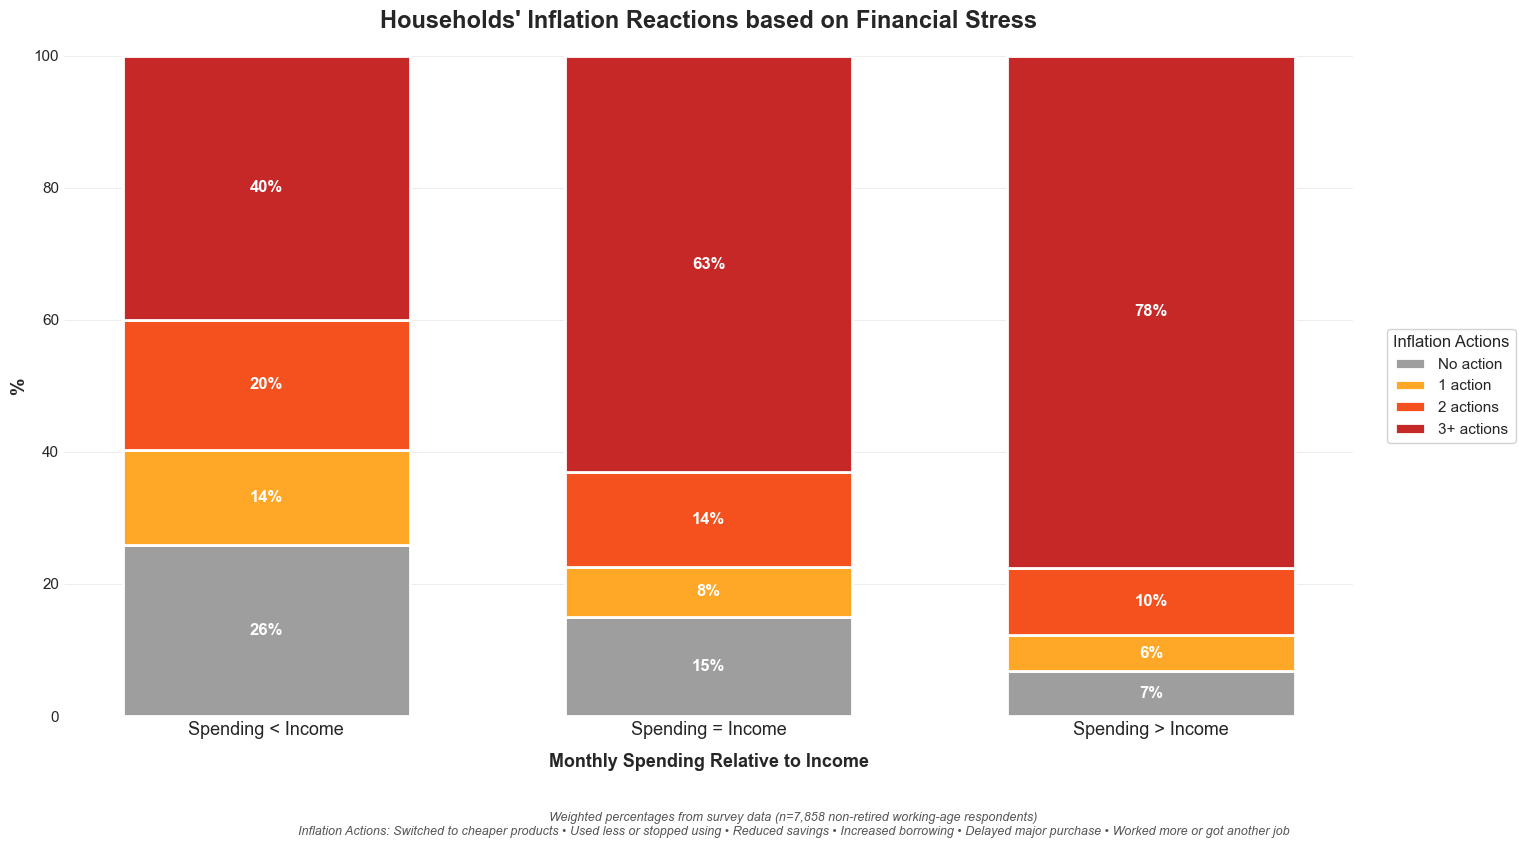


KEY INSIGHTS

Spending < Income:
  No action: 25.9% = 16.7M households
  3+ actions (crisis mode): 40.0% = 25.7M households

Spending = Income:
  No action: 15.0% = 6.1M households
  3+ actions (crisis mode): 63.1% = 25.8M households

Spending > Income:
  No action: 6.8% = 1.8M households
  3+ actions (crisis mode): 77.5% = 21.0M households


In [17]:
# Create 100% stacked bar chart with percentages
import matplotlib.pyplot as plt
import numpy as np

# US household total from FRED
US_HOUSEHOLDS = 132_216_000

# Calculate percentages for each I20 category
i20_values = ['Less than your income', 'The same as your income', 'More than your income']
i20_labels_short = ['Spending < Income', 'Spending = Income', 'Spending > Income']
action_categories = ['No action', '1 action', '2 actions', '3+ actions']

# Calculate total households in each spending category first
category_household_counts = {}
total_weight = df['weight_pop'].sum()
for i20_val, label in zip(i20_values, i20_labels_short):
    subset = df[df['I20'] == i20_val]
    category_weight = subset['weight_pop'].sum()
    category_pct = (category_weight / total_weight) * 100
    category_household_counts[label] = (category_pct / 100) * US_HOUSEHOLDS

# Build percentage matrix and count matrix
pct_matrix = []
count_matrix = []
for i, i20_val in enumerate(i20_values):
    subset = df[df['I20'] == i20_val]
    total = len(subset)
    category_total_households = category_household_counts[i20_labels_short[i]]
    
    row_pcts = []
    row_counts = []
    for action in action_categories:
        count = len(subset[subset['action_category'] == action])
        pct = (count / total) * 100 if total > 0 else 0
        segment_count = (pct / 100) * category_total_households
        row_pcts.append(pct)
        row_counts.append(segment_count)
    pct_matrix.append(row_pcts)
    count_matrix.append(row_counts)

# Convert to numpy arrays
pct_matrix = np.array(pct_matrix)
count_matrix = np.array(count_matrix)

print("Distribution (percentages and household counts):")
for i, i20_label in enumerate(i20_labels_short):
    print(f"\n{i20_label} (Total: {category_household_counts[i20_label]/1_000_000:.1f}M households):")
    for j, action in enumerate(action_categories):
        print(f"  {action:15s}: {pct_matrix[i, j]:5.1f}% = {count_matrix[i, j]/1_000_000:.1f}M")

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8.5), facecolor='white')
ax.set_facecolor('white')

# Color palette
colors = ['#9E9E9E', '#FFA726', '#F4511E', '#C62828']  # Gray, Orange, Deep orange, Dark red

# X positions for bars
x_pos = np.arange(len(i20_labels_short))
bar_width = 0.65

# Create stacked bars
bottom = np.zeros(len(i20_labels_short))
for i, (action, color) in enumerate(zip(action_categories, colors)):
    values = pct_matrix[:, i]
    counts = count_matrix[:, i]
    bars = ax.bar(x_pos, values, bar_width, bottom=bottom, label=action, color=color, edgecolor='white', linewidth=2)
    
    # Add labels with percentage only
    for j, (bar, value, count) in enumerate(zip(bars, values, counts)):
        if value >= 5:  # Only show label if segment is >= 5%
            height = bar.get_height()
            y_pos = bottom[j] + height / 2
            # Format: percentage only - e.g., "26%"
            ax.text(bar.get_x() + bar.get_width() / 2, y_pos, 
                   f'{value:.0f}%',
                   ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    
    bottom += values

# Minimalistic styling
ax.set_ylabel('%', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Spending Relative to Income', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title('Households\' Inflation Reactions based on Financial Stress', 
             fontsize=17, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(i20_labels_short, fontsize=13)
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.yaxis.set_tick_params(labelsize=11)

# Minimal grid
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, color='gray')
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Legend
ax.legend(title='Inflation Actions', loc='center left', bbox_to_anchor=(1.02, 0.5),
         frameon=True, fontsize=11, title_fontsize=12, 
         edgecolor='lightgray', facecolor='white', framealpha=1)

# Footnote
footnote_text = (
    "Weighted percentages from survey data (n=7,858 non-retired working-age respondents)\n"
    "Inflation Actions: Switched to cheaper products • Used less or stopped using • Reduced savings • Increased borrowing • Delayed major purchase • Worked more or got another job"
)
fig.text(0.5, 0.01, footnote_text, ha='center', fontsize=9, color='#555', style='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, right=0.85)
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
for i, i20_label in enumerate(['Spending < Income', 'Spending = Income', 'Spending > Income']):
    no_action_pct = pct_matrix[i, 0]
    no_action_count = count_matrix[i, 0]
    three_plus_pct = pct_matrix[i, 3]
    three_plus_count = count_matrix[i, 3]
    print(f"\n{i20_label}:")
    print(f"  No action: {no_action_pct:.1f}% = {no_action_count/1_000_000:.1f}M households")
    print(f"  3+ actions (crisis mode): {three_plus_pct:.1f}% = {three_plus_count/1_000_000:.1f}M households")

In [18]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("Financial stress drives ESCALATION in coping responses:\n")

# Average actions by I20 status
i20_values = ['Less than your income', 'The same as your income', 'More than your income']
for i20_val in i20_values:
    subset = df[df['I20'] == i20_val]
    avg_actions = subset['action_count'].mean()
    
    # Calculate distribution
    no_action = (subset['action_count'] == 0).sum() / len(subset) * 100
    single = (subset['action_count'] == 1).sum() / len(subset) * 100
    two = (subset['action_count'] == 2).sum() / len(subset) * 100
    three_plus = (subset['action_count'] >= 3).sum() / len(subset) * 100
    
    print(f"{i20_val}:")
    print(f"  Average actions: {avg_actions:.2f}")
    print(f"  No action: {no_action:.1f}% | Single: {single:.1f}% | 2 actions: {two:.1f}% | 3+ actions: {three_plus:.1f}%")
    print()

print("THE ESCALATION PATTERN:")
print("• Stable households: Low action counts, mostly substitution (cheaper products)")
print("• Getting-by households: Mix of 1-2 actions, some savings depletion")
print("• Stressed households: Heavily concentrated in 3+ actions = CRISIS MODE")
print()

# Calculate 3+ actions rate for stressed vs stable
stressed_3plus = (df[df['I20'] == 'More than your income']['action_count'] >= 3).sum() / len(df[df['I20'] == 'More than your income']) * 100
stable_3plus = (df[df['I20'] == 'Less than your income']['action_count'] >= 3).sum() / len(df[df['I20'] == 'Less than your income']) * 100

print(f"Stressed households taking 3+ actions: {stressed_3plus:.1f}%")
print(f"Stable households taking 3+ actions: {stable_3plus:.1f}%")
print(f"Multiplier: {stressed_3plus/stable_3plus:.1f}x")
print()
print("Multiple simultaneous actions = depleted reserves + no margin for error.")
print("This is the operational definition of 'no bandwidth' for technology investment.")


=== KEY INSIGHTS ===

Financial stress drives ESCALATION in coping responses:

Less than your income:
  Average actions: 2.06
  No action: 25.9% | Single: 14.5% | 2 actions: 19.7% | 3+ actions: 40.0%

The same as your income:
  Average actions: 2.96
  No action: 15.0% | Single: 7.6% | 2 actions: 14.3% | 3+ actions: 63.1%

More than your income:
  Average actions: 3.71
  No action: 6.8% | Single: 5.5% | 2 actions: 10.2% | 3+ actions: 77.5%

THE ESCALATION PATTERN:
• Stable households: Low action counts, mostly substitution (cheaper products)
• Getting-by households: Mix of 1-2 actions, some savings depletion
• Stressed households: Heavily concentrated in 3+ actions = CRISIS MODE

Stressed households taking 3+ actions: 77.5%
Stable households taking 3+ actions: 40.0%
Multiplier: 1.9x

Multiple simultaneous actions = depleted reserves + no margin for error.
This is the operational definition of 'no bandwidth' for technology investment.


---
# Chart 4: Financial Stress and Harmful Behaviours
## Slope Graph

**Research Question**: How does financial stress drive households toward behaviors that harm both their financial health and physical well-being?

**Variables**:
- **E1 series** (a-e): Healthcare cost barriers (went without care because couldn't afford)
- **BK2 series** (a-f): Alternative financial services usage (money orders, check cashing, payday loans, etc.)
- **I20**: Spending status (comparing stable vs. stressed households)

**Methodology**: Slope graph comparing weighted percentage (using `weight_pop`) of households engaging in:
1. Delayed at least 1 healthcare service
2. Used at least 1 alternative financial service
3. Both behaviors (comorbidity)

Compare **Stable** (spending < income) vs. **Stressed** (spending ≥ income) households.

**Purpose**: Demonstrates the harmful consequences of financial stress - the gap between stable and stressed households in behaviors that damage both financial stability and physical health.

In [19]:
# Create composite binary variables for harmful behaviors

# Healthcare delays (E1 series: went without care due to cost)
e1_vars = ['E1_a', 'E1_b', 'E1_c', 'E1_d', 'E1_e']
df['delayed_healthcare'] = df[e1_vars].apply(
    lambda row: 'Yes' if (row == 'Yes').any() else 'No', axis=1
)

# Alternative finance usage (BK2 series)
bk2_vars = ['BK2_a', 'BK2_b', 'BK2_c', 'BK2_d', 'BK2_e', 'BK2_f']
df['used_alt_finance'] = df[bk2_vars].apply(
    lambda row: 'Yes' if (row == 'Yes').any() else 'No', axis=1
)

# Both behaviors (comorbidity)
df['both_behaviors'] = (
    (df['delayed_healthcare'] == 'Yes') & (df['used_alt_finance'] == 'Yes')
).apply(lambda x: 'Yes' if x else 'No')

# Create vulnerability category based on delayed_healthcare and used_alt_finance
def categorize_vulnerability(row):
    delayed = row['delayed_healthcare']
    alt_finance = row['used_alt_finance']
    
    if delayed == 'No' and alt_finance == 'No':
        return 'Neither'
    elif delayed == 'No' and alt_finance == 'Yes':
        return 'BK2 only (Predatory finance)'
    elif delayed == 'Yes' and alt_finance == 'No':
        return 'E1 only (Healthcare barriers)'
    else:  # delayed == 'Yes' and alt_finance == 'Yes'
        return 'BOTH (Danger zone)'

df['vulnerability_category'] = df.apply(categorize_vulnerability, axis=1)

print("Composite variables created:")
print(f"Delayed healthcare: {(df['delayed_healthcare'] == 'Yes').sum():,} households")
print(f"Used alt finance: {(df['used_alt_finance'] == 'Yes').sum():,} households")
print(f"Both behaviors: {(df['both_behaviors'] == 'Yes').sum():,} households")
print(f"\nVulnerability category distribution:")
print(df['vulnerability_category'].value_counts())

Composite variables created:
Delayed healthcare: 2,381 households
Used alt finance: 1,769 households
Both behaviors: 970 households

Vulnerability category distribution:
vulnerability_category
Neither                          4678
E1 only (Healthcare barriers)    1411
BOTH (Danger zone)                970
BK2 only (Predatory finance)      799
Name: count, dtype: int64


In [20]:
# Print key insights
print("\n=== KEY INSIGHTS ===\n")
print("The comorbidity of predatory finance and healthcare deprioritization:")
print("")

# Define I20 values
i20_values = ['Less than your income', 'The same as your income', 'More than your income']

# Calculate rates for each I20 group
for i20_val in i20_values:
    subset = df[df['I20'] == i20_val]
    
    # Calculate each category
    neither_pct = (subset['vulnerability_category'] == 'Neither').sum() / len(subset) * 100
    bk2_only_pct = (subset['vulnerability_category'] == 'BK2 only (Predatory finance)').sum() / len(subset) * 100
    e1_only_pct = (subset['vulnerability_category'] == 'E1 only (Healthcare barriers)').sum() / len(subset) * 100
    both_pct = (subset['vulnerability_category'] == 'BOTH (Danger zone)').sum() / len(subset) * 100
    
    print(f"{i20_val}:")
    print(f"  Neither: {neither_pct:.1f}%")
    print(f"  Predatory finance only: {bk2_only_pct:.1f}%")
    print(f"  Healthcare barriers only: {e1_only_pct:.1f}%")
    print(f"  BOTH (danger zone): {both_pct:.1f}%")
    print()

# Calculate multipliers
stable_both = (df[df['I20'] == 'Less than your income']['vulnerability_category'] == 'BOTH (Danger zone)').sum() / len(df[df['I20'] == 'Less than your income']) * 100
stressed_both = (df[df['I20'] == 'More than your income']['vulnerability_category'] == 'BOTH (Danger zone)').sum() / len(df[df['I20'] == 'More than your income']) * 100

print(f"Danger zone multiplier: {stressed_both/stable_both:.1f}x higher among stressed households")
print(f"  Stable: {stable_both:.1f}% | Stressed: {stressed_both:.1f}%")
print()
print("THE TRIPLE THREAT MECHANISM:")
print("Financial stress → Can't afford healthcare → Turn to predatory finance → Deeper in hole")
print("This creates a doom loop: Health deteriorates while debt escalates.")


=== KEY INSIGHTS ===

The comorbidity of predatory finance and healthcare deprioritization:

Less than your income:
  Neither: 75.6%
  Predatory finance only: 7.4%
  Healthcare barriers only: 12.3%
  BOTH (danger zone): 4.7%

The same as your income:
  Neither: 49.8%
  Predatory finance only: 12.2%
  Healthcare barriers only: 23.0%
  BOTH (danger zone): 15.0%

More than your income:
  Neither: 34.7%
  Predatory finance only: 13.9%
  Healthcare barriers only: 24.1%
  BOTH (danger zone): 27.2%

Danger zone multiplier: 5.8x higher among stressed households
  Stable: 4.7% | Stressed: 27.2%

THE TRIPLE THREAT MECHANISM:
Financial stress → Can't afford healthcare → Turn to predatory finance → Deeper in hole
This creates a doom loop: Health deteriorates while debt escalates.


In [21]:
# Calculate weighted percentages for stable vs. stressed households

# Define household groups
stable = df[df['I20'] == 'Less than your income']
stressed = df[df['I20'].isin(['The same as your income', 'More than your income'])]

print(f"Sample sizes:")
print(f"  Stable (spending < income): {len(stable):,} households")
print(f"  Stressed (spending ≥ income): {len(stressed):,} households")

# Calculate weighted percentages for each behavior
def weighted_pct(df_subset, var_name, weight_col='weight_pop'):
    total_weight = df_subset[weight_col].sum()
    if total_weight == 0:
        return 0
    yes_weight = df_subset[df_subset[var_name] == 'Yes'][weight_col].sum()
    return (yes_weight / total_weight) * 100

# Build data for slope graph
behaviors = {
    'delayed_healthcare': 'Delayed a healthcare service',
    'used_alt_finance': 'Used an alternative financial service',
    'both_behaviors': 'Both'
}

slope_data = []
print("\n" + "="*70)
print("Weighted percentages and multipliers:")
print("="*70)

for var, label in behaviors.items():
    stable_pct = weighted_pct(stable, var)
    stressed_pct = weighted_pct(stressed, var)
    multiplier = stressed_pct / stable_pct if stable_pct > 0 else 0
    diff = stressed_pct - stable_pct
    
    slope_data.append({
        'behavior': label,
        'stable': stable_pct,
        'stressed': stressed_pct,
        'multiplier': multiplier,
        'diff': diff
    })
    
    print(f"\n{label}:")
    print(f"  Stable: {stable_pct:.1f}%")
    print(f"  Stressed: {stressed_pct:.1f}%")
    print(f"  Multiplier: {multiplier:.2f}x")
    print(f"  Difference: +{diff:.1f} percentage points")

slope_df = pd.DataFrame(slope_data)

Sample sizes:
  Stable (spending < income): 3,888 households
  Stressed (spending ≥ income): 3,970 households

Weighted percentages and multipliers:

Delayed a healthcare service:
  Stable: 17.7%
  Stressed: 43.1%
  Multiplier: 2.43x
  Difference: +25.3 percentage points

Used an alternative financial service:
  Stable: 13.0%
  Stressed: 33.5%
  Multiplier: 2.58x
  Difference: +20.5 percentage points

Both:
  Stable: 5.1%
  Stressed: 20.2%
  Multiplier: 3.95x
  Difference: +15.1 percentage points


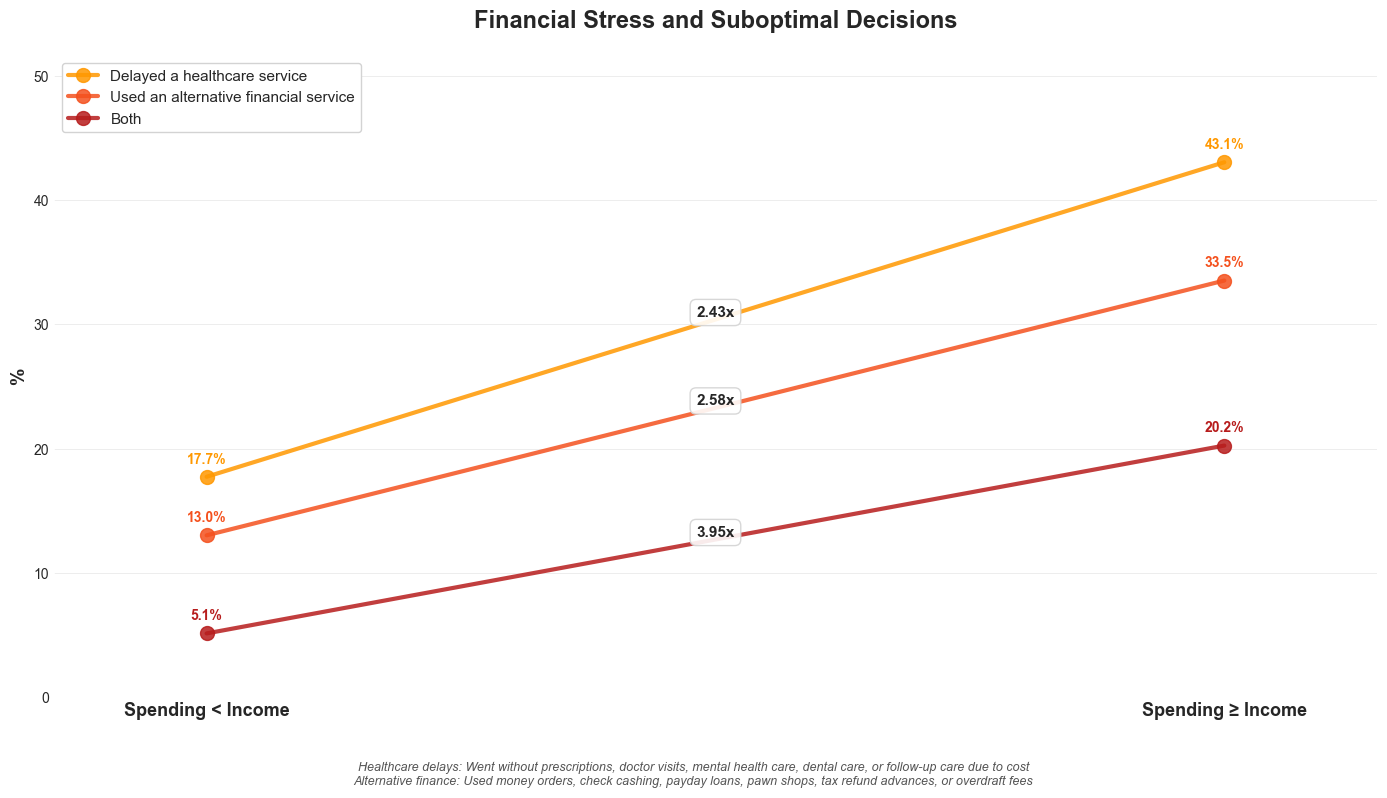


KEY INSIGHT
Stressed households are 3.95x more likely
to engage in BOTH harmful behaviors simultaneously.

Financial stress creates a vicious cycle: using predatory financial
services while simultaneously delaying necessary healthcare.


In [22]:
# Create slope graph with minimalistic aesthetic
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
ax.set_facecolor('white')

# Color palette: gradient from orange to dark red (increasing severity)
colors = {
    'Delayed a healthcare service': '#FF9800',      # Orange
    'Used an alternative financial service': '#F4511E',     # Deep orange/red
    'Both': '#B71C1C'                      # Dark red (most severe)
}

# Plot slope lines
for _, row in slope_df.iterrows():
    behavior = row['behavior']
    ax.plot([0, 1], [row['stable'], row['stressed']],
           marker='o', markersize=10, linewidth=3,
           color=colors[behavior], alpha=0.85,
           label=behavior)
    
    # Add multiplier annotation at midpoint
    mid_y = (row['stable'] + row['stressed']) / 2
    ax.text(0.5, mid_y, f"{row['multiplier']:.2f}x",
           ha='center', va='bottom', fontsize=11, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                    alpha=0.9, edgecolor='lightgray', linewidth=1))

# Add percentage labels centered above the data points
# Calculate offset based on max value for consistent positioning
max_pct = slope_df['stressed'].max()
label_offset = max_pct * 0.02  # 2% of max value

for _, row in slope_df.iterrows():
    behavior = row['behavior']
    # Left point label
    ax.text(0, row['stable'] + label_offset, f"{row['stable']:.1f}%",
           ha='center', va='bottom', fontsize=10, fontweight='bold', 
           color=colors[behavior])
    # Right point label
    ax.text(1, row['stressed'] + label_offset, f"{row['stressed']:.1f}%",
           ha='center', va='bottom', fontsize=10, fontweight='bold',
           color=colors[behavior])

# Configure axes - simplified labels without "Stable/Stressed" classifiers
ax.set_xticks([0, 1])
ax.set_xticklabels(['Spending < Income', 'Spending ≥ Income'],
                  fontsize=13, fontweight='bold')
ax.set_ylabel('%', fontsize=14, fontweight='bold')
ax.set_title('Financial Stress and Suboptimal Decisions',
            fontsize=17, fontweight='bold', pad=20)

# Set y-axis limits with padding for labels above points
ax.set_ylim(0, max_pct * 1.2)

# Set x-axis limits to keep chart centered
ax.set_xlim(-0.15, 1.15)

# Minimal styling
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Legend
ax.legend(loc='upper left', fontsize=11, frameon=True,
         edgecolor='lightgray', facecolor='white', framealpha=1)

# Footnote
footnote_text = (
    "Healthcare delays: Went without prescriptions, doctor visits, mental health care, dental care, or follow-up care due to cost\n"
    "Alternative finance: Used money orders, check cashing, payday loans, pawn shops, tax refund advances, or overdraft fees"
)
fig.text(0.5, 0.01, footnote_text, ha='center', fontsize=9, color='#555', style='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT")
print("="*70)
print(f"Stressed households are {slope_df[slope_df['behavior'] == 'Both']['multiplier'].values[0]:.2f}x more likely")
print("to engage in BOTH harmful behaviors simultaneously.")
print("\nFinancial stress creates a vicious cycle: using predatory financial")
print("services while simultaneously delaying necessary healthcare.")

---
# Chart 5: Income Volatility by Age
## 100% Stacked Bar Charts

**Research Question**: How do income predictability, income change, and spending pressure differ across age groups?

**Variables**:
- **ppagect4**: Age group (`18–29`, `30–44`, `45–59`, `60+`)
- **I9**: Month-to-month income predictability
- **I21_a**: Total monthly income compared to one year ago
- **I20**: Spending relative to income in the past month

**Methodology**: Calculate weighted response distributions using `weight_pop` within each age group, then visualize each variable as a horizontal 100% stacked bar chart.


In [23]:
# Helper functions for age-group income volatility charts
age_order = ['18–29', '30–44', '45–59', '60+']

def weighted_response_distribution(df, response_col, response_order, age_col='ppagect4', weight_col='weight_pop'):
    """Return weighted response percentages within each age group."""
    valid = df[df[age_col].notna() & df[response_col].notna()].copy()
    grouped = (
        valid.groupby([age_col, response_col], observed=True)[weight_col]
        .sum()
        .reset_index()
    )
    matrix = grouped.pivot(index=age_col, columns=response_col, values=weight_col).fillna(0)
    matrix = matrix.reindex(age_order)
    matrix = matrix[[col for col in response_order if col in matrix.columns]]
    matrix = matrix.div(matrix.sum(axis=1), axis=0) * 100
    return matrix.fillna(0)


def print_weighted_distribution_table(matrix, title):
    print(f"\n{title}")
    print("=" * len(title))
    print(matrix.round(1).to_string())



Income Predictability by Age Group
I9        Roughly the same amount each month  Occasionally varies from month to month  Varies quite often from month to month
ppagect4                                                                                                                     
18–29                                   55.6                                     29.3                                    15.1
30–44                                   69.9                                     22.8                                     7.3
45–59                                   71.5                                     20.3                                     8.2
60+                                     67.9                                     22.8                                     9.3


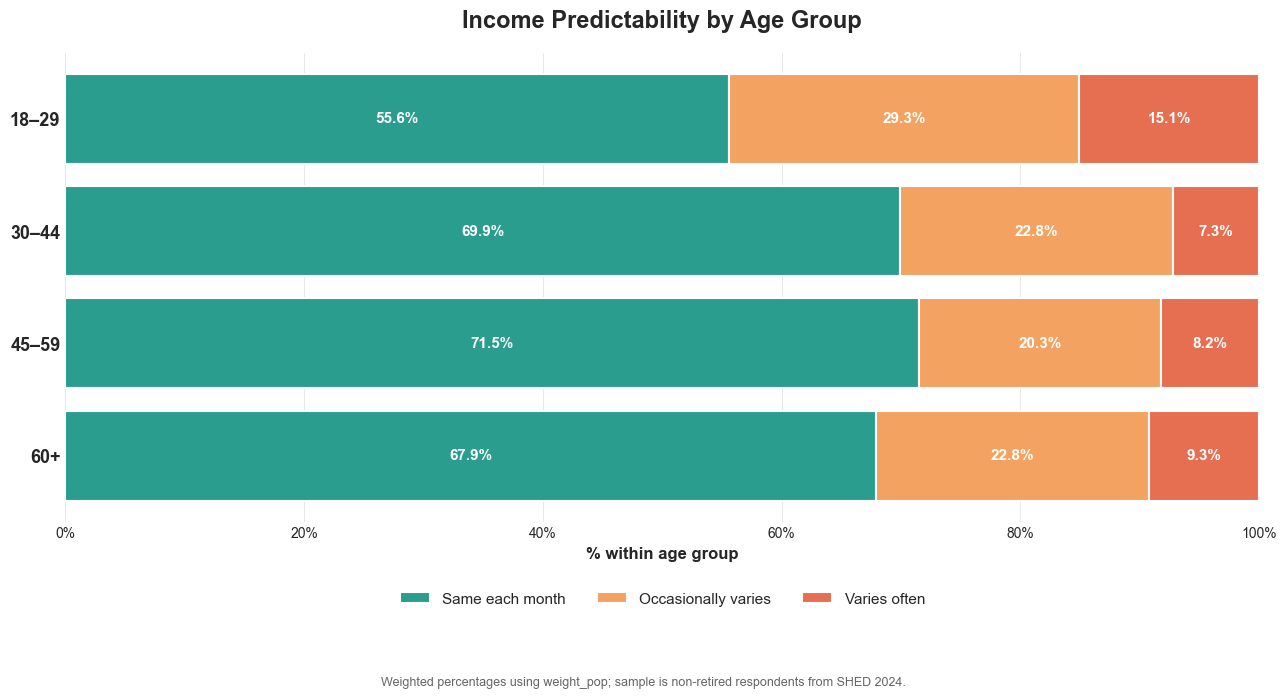


Monthly Income Change by Age Group
I21_a     Increased  About the same  Decreased
ppagect4                                      
18–29          31.6            50.5       17.9
30–44          37.8            48.7       13.6
45–59          33.1            54.4       12.5
60+            30.6            56.9       12.4


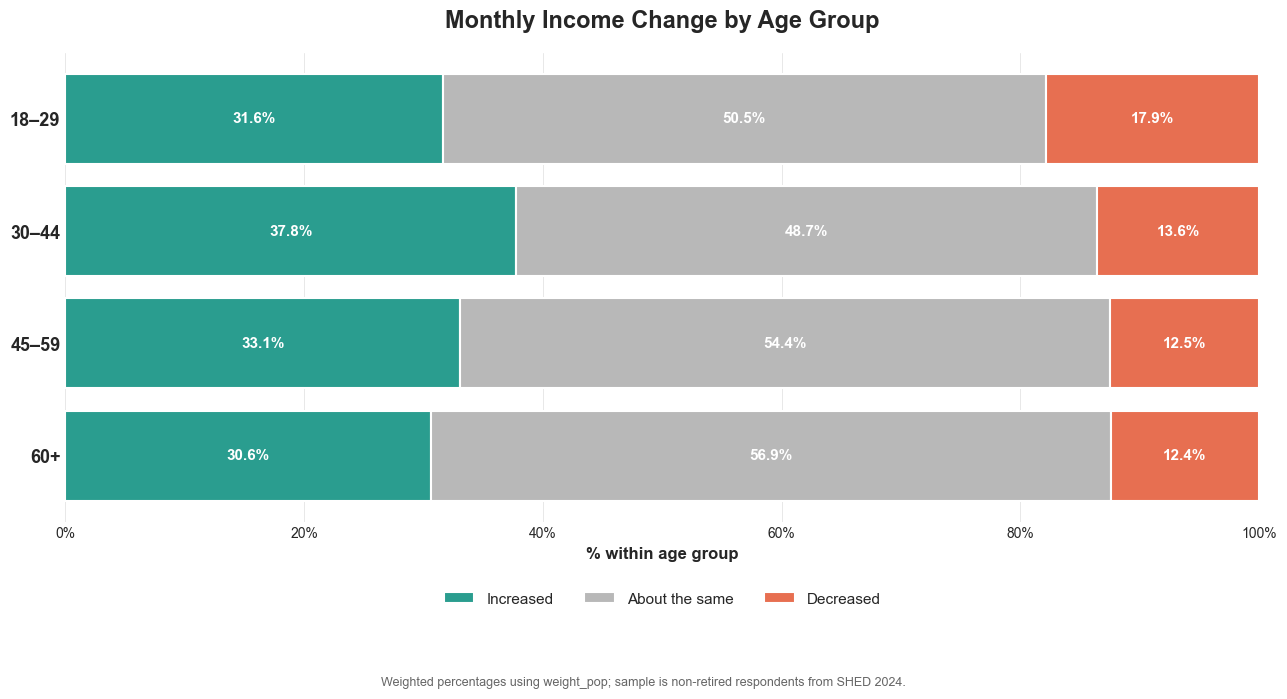


Spending Relative to Income by Age Group
I20       Less than your income  The same as your income  More than your income
ppagect4                                                                       
18–29                      45.7                     32.2                   22.0
30–44                      45.5                     31.9                   22.6
45–59                      50.8                     30.8                   18.3
60+                        60.6                     24.1                   15.3


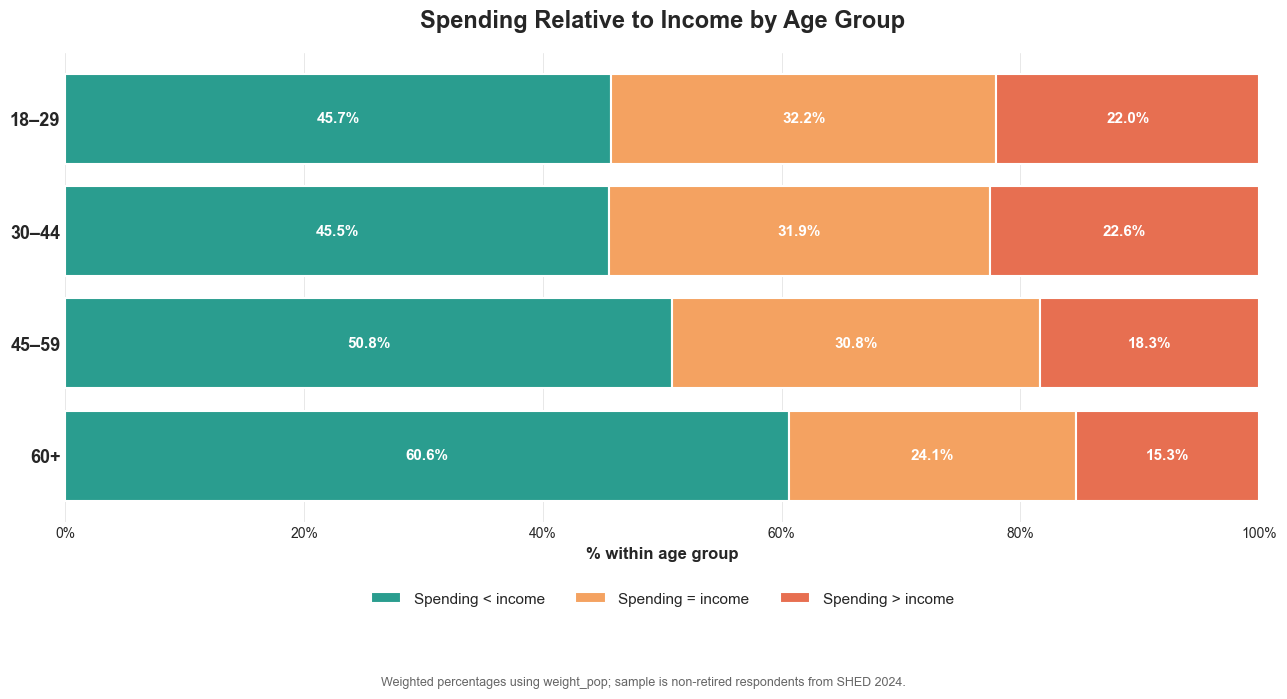

In [24]:
# Create 100% stacked bar charts for income volatility by age
import matplotlib.pyplot as plt
import numpy as np

chart_specs = [
    {
        'response_col': 'I9',
        'title': 'Income Predictability by Age Group',
        'filename': 'income_predictability_by_age',
        'response_order': [
            'Roughly the same amount each month',
            'Occasionally varies from month to month',
            'Varies quite often from month to month'
        ],
        'colors': ['#2A9D8F', '#F4A261', '#E76F51'],
        'legend_labels': ['Same each month', 'Occasionally varies', 'Varies often']
    },
    {
        'response_col': 'I21_a',
        'title': 'Monthly Income Change by Age Group',
        'filename': 'monthly_income_change_by_age',
        'response_order': ['Increased', 'About the same', 'Decreased'],
        'colors': ['#2A9D8F', '#B8B8B8', '#E76F51'],
        'legend_labels': ['Increased', 'About the same', 'Decreased']
    },
    {
        'response_col': 'I20',
        'title': 'Spending Relative to Income by Age Group',
        'filename': 'spending_relative_to_income_by_age',
        'response_order': ['Less than your income', 'The same as your income', 'More than your income'],
        'colors': ['#2A9D8F', '#F4A261', '#E76F51'],
        'legend_labels': ['Spending < income', 'Spending = income', 'Spending > income']
    }
]

for spec in chart_specs:
    matrix = weighted_response_distribution(
        df,
        response_col=spec['response_col'],
        response_order=spec['response_order']
    )
    print_weighted_distribution_table(matrix, spec['title'])

    fig, ax = plt.subplots(figsize=(13, 7), facecolor='white')
    ax.set_facecolor('white')

    y_positions = np.arange(len(matrix.index))
    left = np.zeros(len(matrix.index))

    for response, color, label in zip(matrix.columns, spec['colors'], spec['legend_labels']):
        values = matrix[response].values
        bars = ax.barh(
            y_positions,
            values,
            left=left,
            color=color,
            edgecolor='white',
            linewidth=1.5,
            label=label
        )

        for bar, value, start in zip(bars, values, left):
            if value >= 7:
                ax.text(
                    start + value / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{value:.1f}%',
                    ha='center',
                    va='center',
                    fontsize=11,
                    fontweight='bold',
                    color='white'
                )
            elif value >= 3:
                ax.text(
                    start + value + 0.8,
                    bar.get_y() + bar.get_height() / 2,
                    f'{value:.1f}%',
                    ha='left',
                    va='center',
                    fontsize=9,
                    fontweight='bold',
                    color='#333333'
                )

        left += values

    ax.set_yticks(y_positions)
    ax.set_yticklabels(matrix.index, fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel('% within age group', fontsize=12, fontweight='bold')
    ax.set_title(spec['title'], fontsize=17, fontweight='bold', pad=18)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
    ax.grid(axis='x', alpha=0.18, linestyle='-', linewidth=0.7, color='gray')
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(axis='y', length=0)

    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.12),
        ncol=len(spec['legend_labels']),
        frameon=False,
        fontsize=11
    )

    footnote = 'Weighted percentages using weight_pop; sample is non-retired respondents from SHED 2024.'
    fig.text(0.5, 0.01, footnote, ha='center', fontsize=9, color='#666666')

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    fig.savefig(f"{spec['filename']}.png", dpi=300, bbox_inches='tight', facecolor='white')
    fig.savefig(f"{spec['filename']}.svg", bbox_inches='tight', facecolor='white')
    plt.show()


---
# Chart 6: Income Volatility and Monthly Spending Pressure
## 100% Stacked Bar Chart

**Research Question**: Are households with less predictable income more likely to spend at or above their monthly income?

**Variables**:
- **I9**: Month-to-month income predictability
- **I20**: Spending relative to income in the past month

**Methodology**: Calculate weighted `I20` response distributions using `weight_pop` within each `I9` income-volatility group. Each horizontal bar sums to 100% within the income-volatility group.


Monthly spending position by income volatility
I20                  Spending < income  Spending = income  Spending > income
Same each month                   53.1               29.1               17.8
Occasionally varies               39.8               37.5               22.7
Varies often                      39.9               26.8               33.2


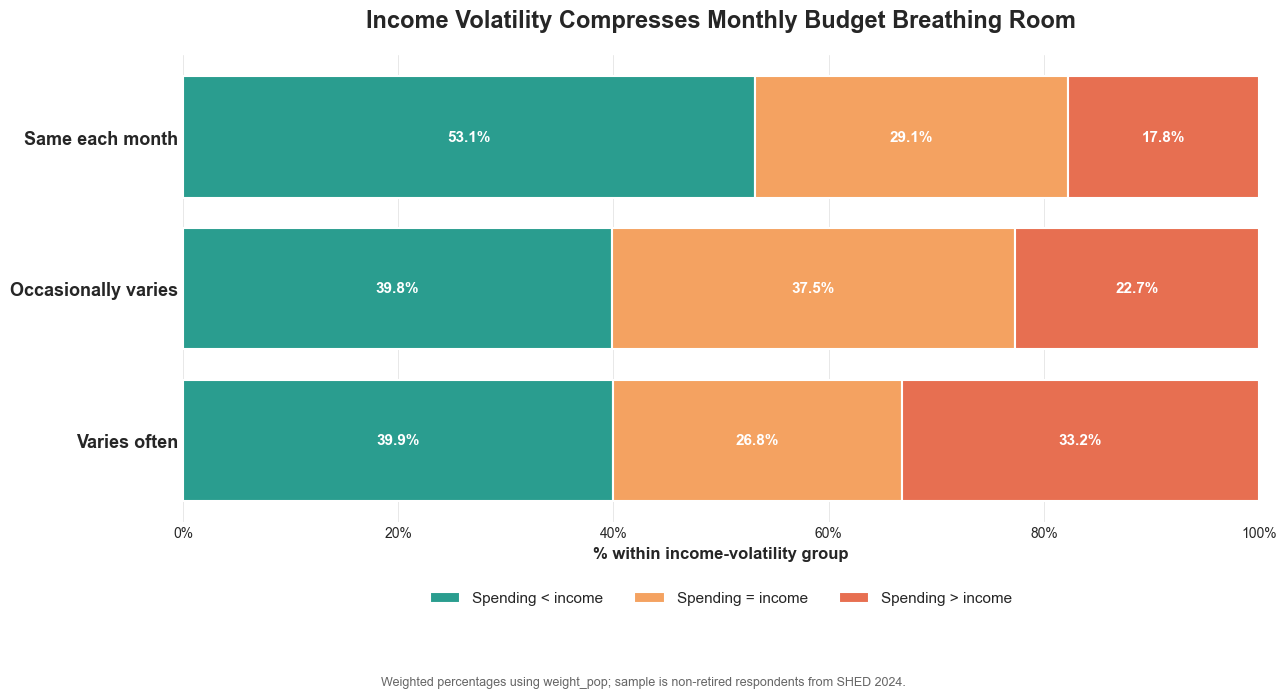

In [25]:
# Chart 6: Income volatility and monthly spending pressure
income_volatility_order = [
    'Roughly the same amount each month',
    'Occasionally varies from month to month',
    'Varies quite often from month to month'
]
income_volatility_labels = {
    'Roughly the same amount each month': 'Same each month',
    'Occasionally varies from month to month': 'Occasionally varies',
    'Varies quite often from month to month': 'Varies often'
}
spending_order = ['Less than your income', 'The same as your income', 'More than your income']
spending_labels = ['Spending < income', 'Spending = income', 'Spending > income']
spending_colors = ['#2A9D8F', '#F4A261', '#E76F51']

valid_spending = df[df['I9'].notna() & df['I20'].notna()].copy()
weighted_counts = (
    valid_spending
    .groupby(['I9', 'I20'], observed=True)['weight_pop']
    .sum()
    .reset_index()
)
spending_matrix = (
    weighted_counts
    .pivot(index='I9', columns='I20', values='weight_pop')
    .fillna(0)
    .reindex(income_volatility_order)
    [spending_order]
)
spending_pct = spending_matrix.div(spending_matrix.sum(axis=1), axis=0) * 100
spending_pct.index = [income_volatility_labels[label] for label in spending_pct.index]

print('Monthly spending position by income volatility')
print('=' * 46)
print(spending_pct.round(1).rename(columns=dict(zip(spending_order, spending_labels))).to_string())

fig, ax = plt.subplots(figsize=(13, 7), facecolor='white')
ax.set_facecolor('white')

y_positions = np.arange(len(spending_pct.index))
left = np.zeros(len(spending_pct.index))

for response, label, color in zip(spending_order, spending_labels, spending_colors):
    values = spending_pct[response].values
    bars = ax.barh(
        y_positions,
        values,
        left=left,
        color=color,
        edgecolor='white',
        linewidth=1.5,
        label=label
    )

    for bar, value, start in zip(bars, values, left):
        ax.text(
            start + value / 2,
            bar.get_y() + bar.get_height() / 2,
            f'{value:.1f}%',
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='white'
        )

    left += values

ax.set_yticks(y_positions)
ax.set_yticklabels(spending_pct.index, fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('% within income-volatility group', fontsize=12, fontweight='bold')
ax.set_title(
    'Income Volatility Compresses Monthly Budget Breathing Room',
    fontsize=17,
    fontweight='bold',
    pad=20
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.grid(axis='x', alpha=0.18, linestyle='-', linewidth=0.7, color='gray')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(axis='y', length=0)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
    fontsize=11
)

footnote = 'Weighted percentages using weight_pop; sample is non-retired respondents from SHED 2024.'
fig.text(0.5, 0.01, footnote, ha='center', fontsize=9, color='#666666')

plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig('income_volatility_monthly_spending_stacked.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('income_volatility_monthly_spending_stacked.svg', bbox_inches='tight', facecolor='white')
plt.show()


---
# Chart 7: Income Volatility and Alternative Financial Services
## Dumbbell Chart

**Research Question**: Are households with variable income more likely to use alternative financial services and bank-fee liquidity products?

**Variables**:
- **I9**: Month-to-month income predictability
- **BK2 series**: Alternative financial services and overdraft fee usage in the past 12 months

**Methodology**: Compare weighted product usage rates using `weight_pop` between households with stable income and households with any income variation. `Stable Income` corresponds to `I9 = Roughly the same amount each month`; `Varied Income` combines `I9 = Occasionally varies from month to month` and `I9 = Varies quite often from month to month`.


BK2 product usage by income stability
                      Product  Stable Income  Varied Income  Gap
                Overdraft fee           10.6           18.1  7.5
    Money order\noutside bank            8.4           11.9  3.4
  Check cashing\noutside bank            5.3           10.7  5.4
Payday loan /\npayday advance            3.7            6.2  2.5
      Pawn / auto\ntitle loan            1.9            4.0  2.1
          Tax refund\nadvance            1.5            2.7  1.2


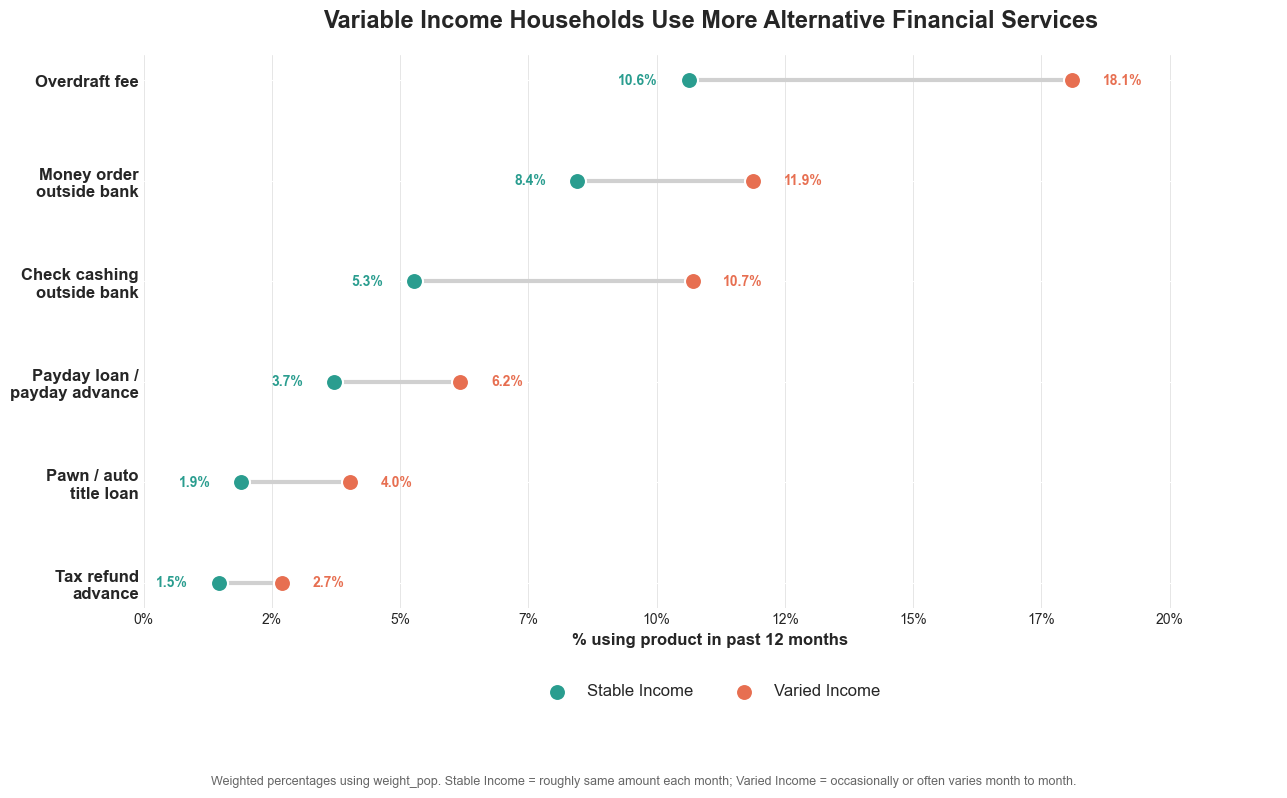

In [26]:
# Chart 6: Dumbbell chart comparing BK2 usage by income stability
bk2_products = {
    'BK2_a': 'Money order\noutside bank',
    'BK2_b': 'Check cashing\noutside bank',
    'BK2_c': 'Payday loan /\npayday advance',
    'BK2_d': 'Pawn / auto\ntitle loan',
    'BK2_e': 'Tax refund\nadvance',
    'BK2_f': 'Overdraft fee'
}

stable_income = df[df['I9'] == 'Roughly the same amount each month']
varied_income = df[df['I9'].isin([
    'Occasionally varies from month to month',
    'Varies quite often from month to month'
])]

def weighted_yes_pct(df_subset, col, weight_col='weight_pop'):
    valid = df_subset[df_subset[col].notna()].copy()
    total_weight = valid[weight_col].sum()
    if total_weight == 0:
        return 0
    yes_weight = valid.loc[valid[col] == 'Yes', weight_col].sum()
    return yes_weight / total_weight * 100

bk2_rows = []
for col, label in bk2_products.items():
    stable_pct = weighted_yes_pct(stable_income, col)
    varied_pct = weighted_yes_pct(varied_income, col)
    bk2_rows.append({
        'product': label,
        'stable_income': stable_pct,
        'varied_income': varied_pct,
        'gap': varied_pct - stable_pct
    })

bk2_dumbbell_df = pd.DataFrame(bk2_rows).sort_values('varied_income', ascending=True)

print('BK2 product usage by income stability')
print('=' * 43)
print(
    bk2_dumbbell_df
    .sort_values('varied_income', ascending=False)
    .assign(
        stable_income=lambda x: x['stable_income'].round(1),
        varied_income=lambda x: x['varied_income'].round(1),
        gap=lambda x: x['gap'].round(1)
    )
    .rename(columns={
        'product': 'Product',
        'stable_income': 'Stable Income',
        'varied_income': 'Varied Income',
        'gap': 'Gap'
    })
    .to_string(index=False)
)

fig, ax = plt.subplots(figsize=(13, 8), facecolor='white')
ax.set_facecolor('white')

y_positions = np.arange(len(bk2_dumbbell_df))

# Connecting lines
for y, (_, row) in zip(y_positions, bk2_dumbbell_df.iterrows()):
    ax.plot(
        [row['stable_income'], row['varied_income']],
        [y, y],
        color='#D0D0D0',
        linewidth=3,
        solid_capstyle='round',
        zorder=1
    )

# Points
ax.scatter(
    bk2_dumbbell_df['stable_income'],
    y_positions,
    s=150,
    color='#2A9D8F',
    edgecolor='white',
    linewidth=1.5,
    label='Stable Income',
    zorder=3
)
ax.scatter(
    bk2_dumbbell_df['varied_income'],
    y_positions,
    s=150,
    color='#E76F51',
    edgecolor='white',
    linewidth=1.5,
    label='Varied Income',
    zorder=3
)

# Value labels
for y, (_, row) in zip(y_positions, bk2_dumbbell_df.iterrows()):
    ax.text(
        row['stable_income'] - 0.6,
        y,
        f"{row['stable_income']:.1f}%",
        ha='right',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#2A9D8F'
    )
    ax.text(
        row['varied_income'] + 0.6,
        y,
        f"{row['varied_income']:.1f}%",
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#E76F51'
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(bk2_dumbbell_df['product'], fontsize=12, fontweight='bold')
ax.set_xlabel('% using product in past 12 months', fontsize=12, fontweight='bold')
ax.set_title(
    'Variable Income Households Use More Alternative Financial Services',
    fontsize=17,
    fontweight='bold',
    pad=20
)

ax.set_xlim(0, max(bk2_dumbbell_df['varied_income'].max(), bk2_dumbbell_df['stable_income'].max()) + 4)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.grid(axis='x', alpha=0.2, linestyle='-', linewidth=0.7, color='gray')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(axis='y', length=0)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.11),
    ncol=2,
    frameon=False,
    fontsize=12
)

footnote = (
    'Weighted percentages using weight_pop. Stable Income = roughly same amount each month; '
    'Varied Income = occasionally or often varies month to month.'
)
fig.text(0.5, 0.01, footnote, ha='center', fontsize=9, color='#666666')

plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig('bk2_usage_by_income_stability_dumbbell.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('bk2_usage_by_income_stability_dumbbell.svg', bbox_inches='tight', facecolor='white')
plt.show()


---
# Chart 8: Spending Pressure and Alternative Financial Services
## Slope Chart and Heatmap

**Research Question**: How does BK2 product usage change as households move from spending less than income to spending more than income?

**Variables**:
- **I20**: Spending relative to income in the past month
- **BK2 series**: Alternative financial services and overdraft fee usage in the past 12 months

**Methodology**: Calculate weighted product usage rates using `weight_pop` within each spending-relative-to-income group. The slope chart emphasizes the directional increase from spending surplus to deficit; the heatmap shows the full product-by-spending-position pattern.


BK2 product usage by spending relative to income
                      Product  Spending < income  Spending = income  Spending > income  Gap
                Overdraft fee                5.6               15.7               27.6 22.0
    Money order\noutside bank                6.4               11.2               14.9  8.5
  Check cashing\noutside bank                4.0                8.5               12.3  8.2
Payday loan /\npayday advance                1.7                5.3               10.2  8.5
      Pawn / auto\ntitle loan                1.3                2.7                5.7  4.4
          Tax refund\nadvance                0.9                2.0                4.0  3.1


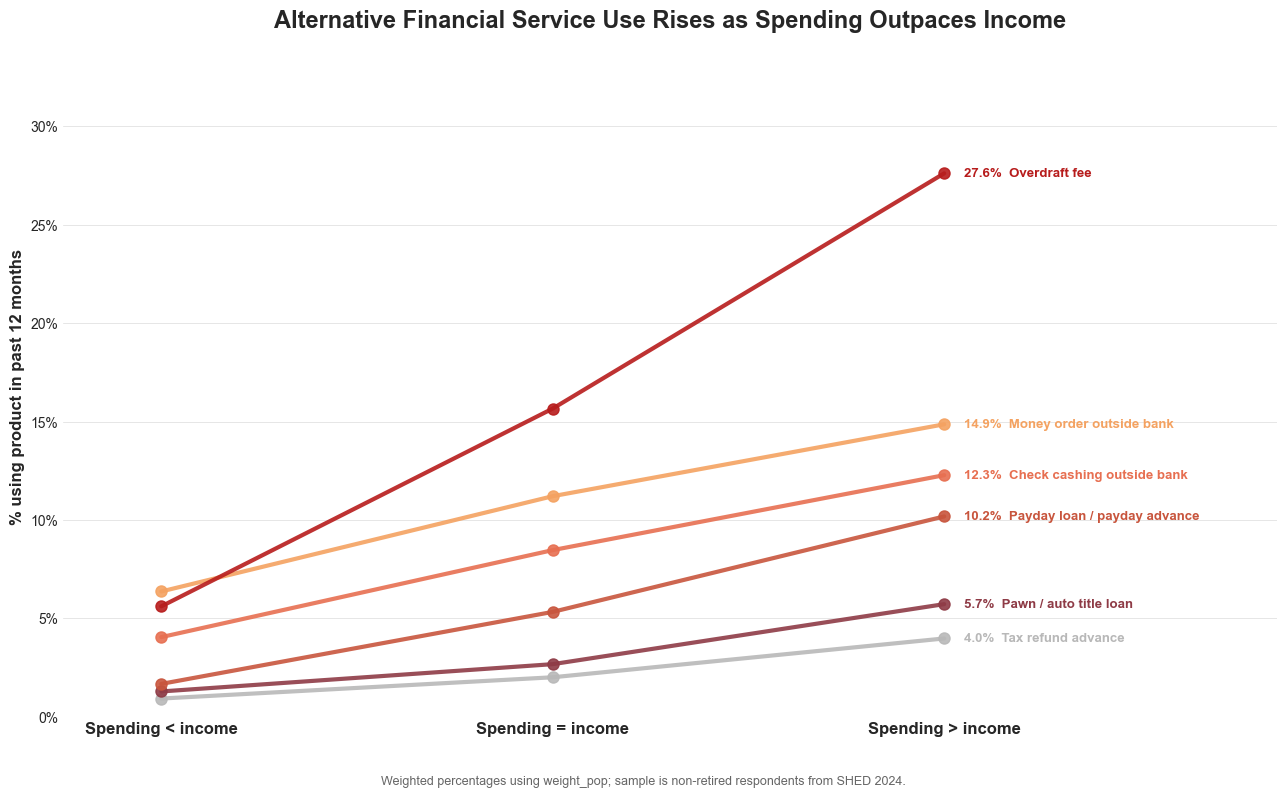

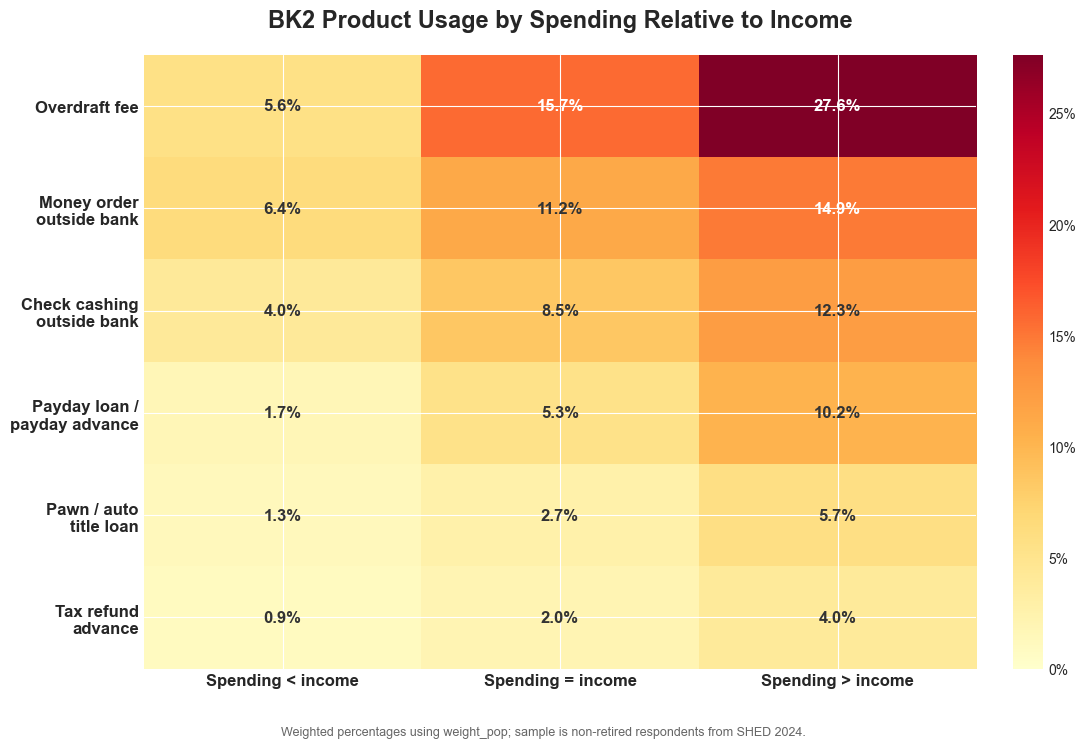

In [27]:
# Chart 7: Spending pressure and BK2 usage
bk2_i20_products = {
    'BK2_a': 'Money order\noutside bank',
    'BK2_b': 'Check cashing\noutside bank',
    'BK2_c': 'Payday loan /\npayday advance',
    'BK2_d': 'Pawn / auto\ntitle loan',
    'BK2_e': 'Tax refund\nadvance',
    'BK2_f': 'Overdraft fee'
}

i20_groups = {
    'Spending < income': 'Less than your income',
    'Spending = income': 'The same as your income',
    'Spending > income': 'More than your income'
}

def weighted_yes_pct_valid(df_subset, col, weight_col='weight_pop'):
    valid = df_subset[df_subset[col].notna()].copy()
    total_weight = valid[weight_col].sum()
    if total_weight == 0:
        return 0
    yes_weight = valid.loc[valid[col] == 'Yes', weight_col].sum()
    return yes_weight / total_weight * 100

i20_bk2_rows = []
for col, label in bk2_i20_products.items():
    row = {'product': label}
    for group_label, group_value in i20_groups.items():
        subset = df[df['I20'] == group_value]
        row[group_label] = weighted_yes_pct_valid(subset, col)
    row['gap'] = row['Spending > income'] - row['Spending < income']
    i20_bk2_rows.append(row)

i20_bk2_df = pd.DataFrame(i20_bk2_rows).sort_values('Spending > income', ascending=False)

print('BK2 product usage by spending relative to income')
print('=' * 51)
print(
    i20_bk2_df
    .assign(**{
        'Spending < income': lambda x: x['Spending < income'].round(1),
        'Spending = income': lambda x: x['Spending = income'].round(1),
        'Spending > income': lambda x: x['Spending > income'].round(1),
        'gap': lambda x: x['gap'].round(1)
    })
    .rename(columns={'product': 'Product', 'gap': 'Gap'})
    .to_string(index=False)
)

# Slope chart
slope_df = i20_bk2_df.sort_values('gap', ascending=True).copy()
fig, ax = plt.subplots(figsize=(13, 8), facecolor='white')
ax.set_facecolor('white')

colors = {
    'Money order\noutside bank': '#F4A261',
    'Check cashing\noutside bank': '#E76F51',
    'Payday loan /\npayday advance': '#C8553D',
    'Pawn / auto\ntitle loan': '#8E3B46',
    'Tax refund\nadvance': '#B8B8B8',
    'Overdraft fee': '#B71C1C'
}

x_positions = [0, 1, 2]
x_labels = list(i20_groups.keys())

for _, row in slope_df.iterrows():
    values = [row[label] for label in x_labels]
    ax.plot(
        x_positions,
        values,
        marker='o',
        markersize=8,
        linewidth=3,
        color=colors[row['product']],
        alpha=0.9
    )
    ax.text(
        2.05,
        values[2],
        f"{values[2]:.1f}%  {row['product'].replace(chr(10), ' ')}",
        ha='left',
        va='center',
        fontsize=9.5,
        fontweight='bold',
        color=colors[row['product']]
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12, fontweight='bold')
ax.set_ylabel('% using product in past 12 months', fontsize=12, fontweight='bold')
ax.set_title(
    'Alternative Financial Service Use Rises as Spending Outpaces Income',
    fontsize=17,
    fontweight='bold',
    pad=20
)
ax.set_xlim(-0.25, 2.85)
ax.set_ylim(0, slope_df['Spending > income'].max() + 6)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.7, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

footnote = 'Weighted percentages using weight_pop; sample is non-retired respondents from SHED 2024.'
fig.text(0.5, 0.01, footnote, ha='center', fontsize=9, color='#666666')

plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig('bk2_usage_by_spending_pressure_slope.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('bk2_usage_by_spending_pressure_slope.svg', bbox_inches='tight', facecolor='white')
plt.show()

# Heatmap
heatmap_df = i20_bk2_df.set_index('product')[x_labels].sort_values('Spending > income', ascending=False)
fig, ax = plt.subplots(figsize=(11, 7.5), facecolor='white')
ax.set_facecolor('white')

im = ax.imshow(heatmap_df.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=heatmap_df.values.max())

ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, fontsize=12, fontweight='bold')
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=12, fontweight='bold')

for i in range(len(heatmap_df.index)):
    for j in range(len(x_labels)):
        value = heatmap_df.iloc[i, j]
        text_color = 'white' if value >= 14 else '#333333'
        ax.text(
            j,
            i,
            f'{value:.1f}%',
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold',
            color=text_color
        )

ax.set_title(
    'BK2 Product Usage by Spending Relative to Income',
    fontsize=17,
    fontweight='bold',
    pad=20
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(top=False, bottom=False, left=False, right=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_visible(False)

fig.text(0.5, 0.01, footnote, ha='center', fontsize=9, color='#666666')

plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig('bk2_usage_by_spending_pressure_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('bk2_usage_by_spending_pressure_heatmap.svg', bbox_inches='tight', facecolor='white')
plt.show()
